# Part A – Theoretical Foundation (Short Notes & Explanation)

## 1. What is Statistical Distribution?

A statistical distribution describes how the values of a variable are spread over a range. It shows the frequency or probability of different outcomes in a dataset. Distributions help in understanding the behavior, central tendency, and variability of data.

Statistical distributions are mainly classified into:

- **Discrete Distribution** – Deals with countable values.
- **Continuous Distribution** – Deals with measurable values.

Examples:
- Binomial Distribution
- Poisson Distribution
- Normal Distribution

Distributions are widely used in data analysis, probability theory, machine learning, and statistical modeling.

---

## 2. What is a Q-Q Plot and Why is it Used?

A **Q-Q Plot (Quantile-Quantile Plot)** is a graphical method used to compare two probability distributions by plotting their quantiles against each other.

It is mainly used to check whether a dataset follows a normal distribution.

### Uses of Q-Q Plot:
- To check normality of data.
- To identify skewness and outliers.
- To compare two distributions.

### Interpretation:
- If points lie approximately on a straight line, the data follows the compared distribution.
- Large deviations indicate non-normality.

---

## 3. Difference Between Discrete and Continuous Distributions

| Discrete Distribution | Continuous Distribution |
|----------------------|-------------------------|
| Takes countable values | Takes measurable values |
| Values are separate | Values are within intervals |
| Uses Probability Mass Function (PMF) | Uses Probability Density Function (PDF) |
| Example: Number of students | Example: Height, weight |

### Examples:
- Discrete: Binomial, Poisson
- Continuous: Normal, Exponential

---

## 4. What is Bernoulli Distribution?

Bernoulli Distribution is a discrete probability distribution with only two possible outcomes:

- Success (1)
- Failure (0)

It is used for experiments with a single trial.

### Formula:

\[
P(X=x) = p^x (1-p)^{1-x}
\]

Where:
- \(p\) = probability of success
- \(1-p\) = probability of failure

### Example:
Tossing a coin:
- Head = Success
- Tail = Failure

---

## 5. What is Binomial Distribution?

Binomial Distribution represents the number of successes in a fixed number of independent Bernoulli trials.

### Conditions:
- Fixed number of trials
- Only two outcomes
- Probability remains constant
- Trials are independent

### Formula:

\[
P(X=x) = \binom{n}{x} p^x (1-p)^{n-x}
\]

Where:
- \(n\) = total trials
- \(x\) = number of successes
- \(p\) = probability of success

### Example:
Finding the probability of getting 3 heads in 5 coin tosses.

---

## 6. Explain Log-Normal Distribution

A Log-Normal Distribution is a probability distribution where the logarithm of the variable follows a normal distribution.

If:

\[
Y = \ln(X)
\]

and \(Y\) is normally distributed, then \(X\) follows a log-normal distribution.

### Characteristics:
- Positively skewed
- Values are always positive
- Used for financial and biological data

### Applications:
- Stock prices
- Income distribution
- Growth rates

---

## 7. Explain Power Law Distribution

Power Law Distribution describes relationships where small values occur frequently and large values occur rarely.

### Formula:

\[
P(x) \propto x^{-\alpha}
\]

Where:
- \(\alpha\) = scaling parameter

### Characteristics:
- Heavy tail distribution
- Large events are rare but possible

### Applications:
- Earthquakes
- Social networks
- Wealth distribution

---

## 8. What is Box-Cox Transform?

Box-Cox Transformation is a mathematical transformation used to make data more normally distributed.

It helps improve:
- Normality
- Variance stability
- Model performance

### Formula:

\[
Y(\lambda)=
\begin{cases}
\frac{Y^\lambda - 1}{\lambda}, & \lambda \neq 0 \\
\ln(Y), & \lambda = 0
\end{cases}
\]

### Uses:
- Data preprocessing
- Regression analysis
- Reducing skewness

---

## 9. Explain Poisson Distribution with an Example

Poisson Distribution is used to model the number of events occurring within a fixed interval of time or space.

### Formula:

\[
P(X=x)=\frac{e^{-\lambda}\lambda^x}{x!}
\]

Where:
- \(\lambda\) = average number of events
- \(x\) = number of occurrences

### Example:
Number of customer calls received per hour in a call center.

### Characteristics:
- Events occur independently
- Average rate remains constant

---

## 10. What is Z-score Probability?

Z-score represents how many standard deviations a data point is away from the mean.

### Formula:

\[
Z = \frac{X - \mu}{\sigma}
\]

Where:
- \(X\) = data value
- \(\mu\) = mean
- \(\sigma\) = standard deviation

### Uses:
- Standardizing data
- Finding probabilities in normal distribution
- Detecting outliers

### Interpretation:
- Positive Z-score → Above mean
- Negative Z-score → Below mean

---

## 11. Differentiate Probability Density Function (PDF) and Cumulative Distribution Function (CDF)

| PDF | CDF |
|-----|-----|
| Shows probability density | Shows cumulative probability |
| Used for continuous variables | Gives probability up to a value |
| Area under curve = probability | Value ranges from 0 to 1 |
| Derivative of CDF | Integral of PDF |

### PDF:
Probability Density Function describes the relative likelihood of a continuous random variable.

### CDF:
Cumulative Distribution Function gives the probability that a variable is less than or equal to a specific value.

\[
CDF(x) = P(X \leq x)
\]

---

In [47]:
import numpy as np
import pandas as pd
import scipy.stats as stats
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import bernoulli, binom, poisson, lognorm, powerlaw, boxcox, zscore

In [48]:
df = pd.read_csv("spread_locator_dataset - spread_locator_dataset.csv.csv")

print("Dataset Shape:", df.shape)
df.info()
df.describe()

Dataset Shape: (220, 7)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 220 entries, 0 to 219
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   transaction_id      220 non-null    object 
 1   customer_id         220 non-null    object 
 2   transaction_amount  220 non-null    float64
 3   transaction_date    220 non-null    object 
 4   transaction_count   220 non-null    int64  
 5   region              220 non-null    object 
 6   transaction_status  220 non-null    object 
dtypes: float64(1), int64(1), object(5)
memory usage: 12.2+ KB


,transaction_amount,transaction_count
count,220.000000,220.000000
mean,3365.192409,2.854545
std,1985.705409,1.797189
min,804.420000,0.000000
25%,2124.205000,1.750000
50%,3077.715000,3.000000
75%,3950.737500,4.000000
max,20462.840000,9.000000


In [49]:
df.isnull().sum()

transaction_id        0
customer_id           0
transaction_amount    0
transaction_date      0
transaction_count     0
region                0
transaction_status    0
dtype: int64

In [50]:
df['transaction_date'] = pd.to_datetime(df['transaction_date'])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 220 entries, 0 to 219
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   transaction_id      220 non-null    object        
 1   customer_id         220 non-null    object        
 2   transaction_amount  220 non-null    float64       
 3   transaction_date    220 non-null    datetime64[ns]
 4   transaction_count   220 non-null    int64         
 5   region              220 non-null    object        
 6   transaction_status  220 non-null    object        
dtypes: datetime64[ns](1), float64(1), int64(1), object(4)
memory usage: 12.2+ KB


In [51]:
print("Bernoulli Distribution:")
df['status_binary'] = df['transaction_status'].map({ 'Success': 1, 'Fail': 0 })
p = df['status_binary'].mean()
print("Probability of Success", p)
#------------------------------------------------------------------------------------------------------------------------------------------------------
print("\nBinomial Distribution:")
n = df['transaction_count'].max()
x = 5
binomial_prob = binom.pmf(x, n, p)
print(f"Probability of exactly {x} successes in {n} trials: {binomial_prob}")


Bernoulli Distribution:
Probability of Success 0.44545454545454544

Binomial Distribution:
Probability of exactly 5 successes in 9 trials: 0.2089951071757113


In [52]:
lambda_value = df['transaction_count'].mean()
print("\nLambda Value", lambda_value)

poisson_prob = poisson.pmf(df['transaction_count'], lambda_value)
print(poisson_prob[:10])


Lambda Value 2.8545454545454545
[0.22322678 0.05758199 0.05758199 0.2346014  0.15930275 0.1643704
 0.09094739 0.22322678 0.05758199 0.15930275]


In [53]:
#Log Normal

shape, loc, scale = lognorm.fit(df['transaction_amount'])

print("Shape:", shape)
print("Location:", loc)
print("Scale:", scale)

Shape: 0.5416831487801056
Location: 333.7722748609052
Scale: 2604.740667049811


In [54]:
#Power Law Distribution

params = powerlaw.fit(df['transaction_amount'])

print("Power Law Parameters:", params)

Power Law Parameters: (np.float64(0.41232325172331613), np.float64(804.4199999999998), np.float64(19658.420000000006))


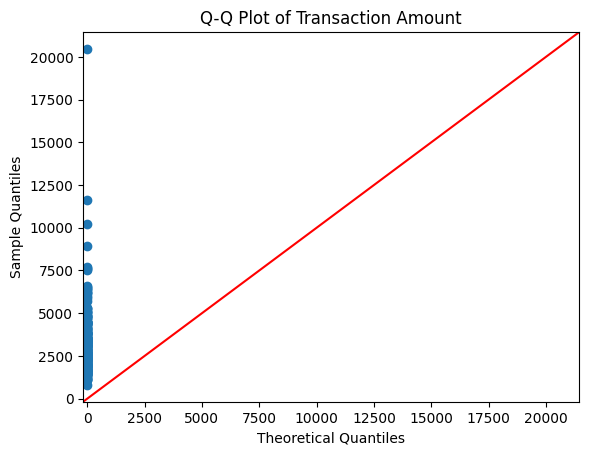

In [55]:
# Q-Q Plot
sm.qqplot(df['transaction_amount'], line='45')

plt.title("Q-Q Plot of Transaction Amount")
plt.show()

In [56]:

boxcox_data, lambda_value = boxcox(df['transaction_amount'])

print("Lambda Value:", lambda_value)
print("Boxcox Value:", boxcox_data[:10])

Lambda Value: -0.18083390743966327
Boxcox Value: [4.28561065 4.21207995 4.30248114 4.39588421 4.20060422 4.20060603
 4.40163039 4.31569915 4.17201743 4.29075812]


In [57]:
df['z_score'] = zscore(df['transaction_amount'])
df[['transaction_amount', 'z_score']].head()

mean = df['transaction_amount'].mean()
std = df['transaction_amount'].std()

probability = 1 - stats.norm.cdf(5000, mean, std)
print("Mean:", mean)
print("Standard Deviation:", std)
print("Probability of Transaction Amount > 5000:", probability)

Mean: 3365.1924090909088
Standard Deviation: 1985.705409161596
Probability of Transaction Amount > 5000: 0.20517209567554384


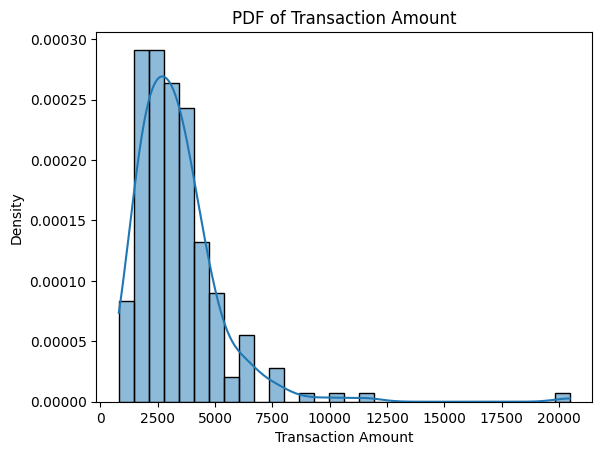

In [58]:
sns.histplot(df['transaction_amount'], kde=True, stat='density')

plt.title("PDF of Transaction Amount")
plt.xlabel("Transaction Amount")
plt.ylabel("Density")

plt.show()

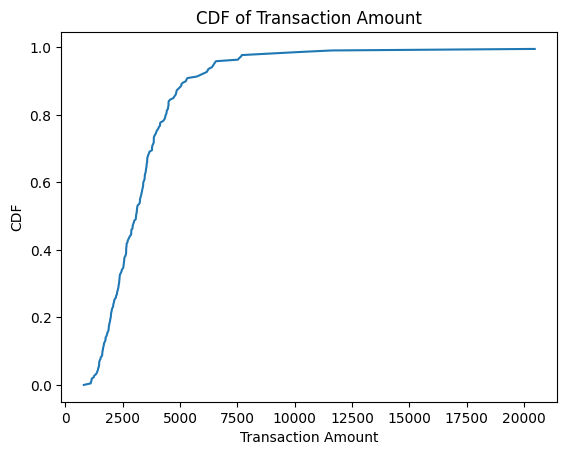

In [59]:
sorted_data = np.sort(df['transaction_amount'])

cdf = np.arange(len(sorted_data)) / float(len(sorted_data))

plt.plot(sorted_data, cdf)
plt.title("CDF of Transaction Amount")
plt.xlabel("Transaction Amount")
plt.ylabel("CDF")

plt.show()

In [60]:
print("""
Conclusion:

1. Bernoulli distribution was used for transaction success/failure analysis.
2. Binomial distribution modeled weekly transaction counts.
3. Poisson distribution analyzed transaction occurrence frequency.
4. Q-Q Plot showed whether data follows normal distribution.
5. Box-Cox transformation helped stabilize variance.
6. Z-score identified outliers in transaction amounts.
7. PDF and CDF visualized transaction amount distribution.

Based on analysis, the best-fitting distribution can be determined by observing:
- Q-Q Plot alignment
- Distribution fitting parameters
- Shape of PDF and CDF
""")


Conclusion:

1. Bernoulli distribution was used for transaction success/failure analysis.
2. Binomial distribution modeled weekly transaction counts.
3. Poisson distribution analyzed transaction occurrence frequency.
4. Q-Q Plot showed whether data follows normal distribution.
5. Box-Cox transformation helped stabilize variance.
6. Z-score identified outliers in transaction amounts.
7. PDF and CDF visualized transaction amount distribution.

Based on analysis, the best-fitting distribution can be determined by observing:
- Q-Q Plot alignment
- Distribution fitting parameters
- Shape of PDF and CDF

